In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")

##### Q3 Gaussians

In [13]:
X = [5, 7, 7, 8, 10]
h = 1.5
x = [6.0, 6.5, 7.0, 8.0, 8.5]

import numpy as np

X = np.array([5, 7, 7, 8, 10])
h = 1.5

x_values = np.array([6.0, 6.5, 7.0, 8.0, 8.5])

n = len(X)

for x in x_values:
    kde = np.mean(
        (1 / (h * np.sqrt(2 * np.pi))) *
        np.exp(-0.5 * ((x - X) / h)**2)
    )
    
    print(x, kde)

6.0 0.15116667696891306
6.5 0.1686573058023977
7.0 0.1780444810019199
8.0 0.16744524435137587
8.5 0.15060230537921773


### Question 4

##### Part A

In [10]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator')
    plt.show()
    return x_grid, f_hat

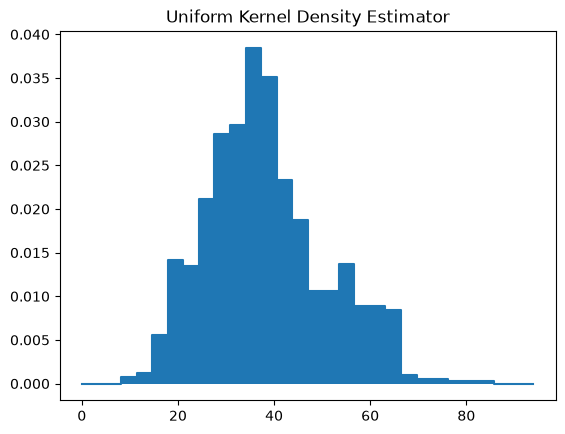

(array([ 0.09571897,  3.33049697,  6.56527498,  9.80005298, 13.03483098,
        16.26960898, 19.50438698, 22.73916499, 25.97394299, 29.20872099,
        32.44349899, 35.67827699, 38.913055  , 42.147833  , 45.382611  ,
        48.617389  , 51.852167  , 55.086945  , 58.32172301, 61.55650101,
        64.79127901, 68.02605701, 71.26083501, 74.49561302, 77.73039102,
        80.96516902, 84.19994702, 87.43472502, 90.66950303, 93.90428103]),
 array([0.        , 0.        , 0.        , 0.00072161, 0.00120268,
        0.00553233, 0.01419163, 0.01347002, 0.02116718, 0.0286238 ,
        0.02958594, 0.03848578, 0.03511827, 0.023332  , 0.01876182,
        0.01058359, 0.01058359, 0.01371056, 0.00889984, 0.00889984,
        0.00841876, 0.00096214, 0.00048107, 0.00048107, 0.00024054,
        0.00024054, 0.00024054, 0.        , 0.        , 0.        ]))

In [11]:
kde(df['ejection_fraction'])

##### Part B


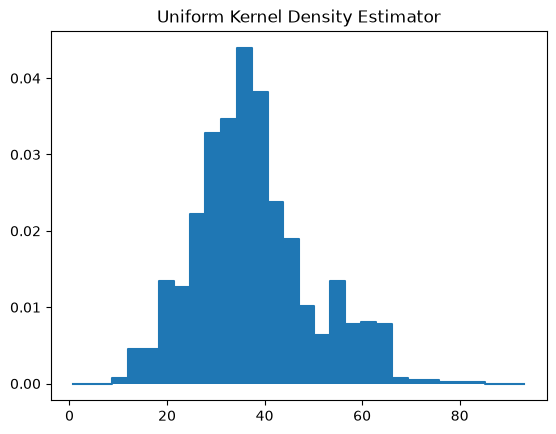

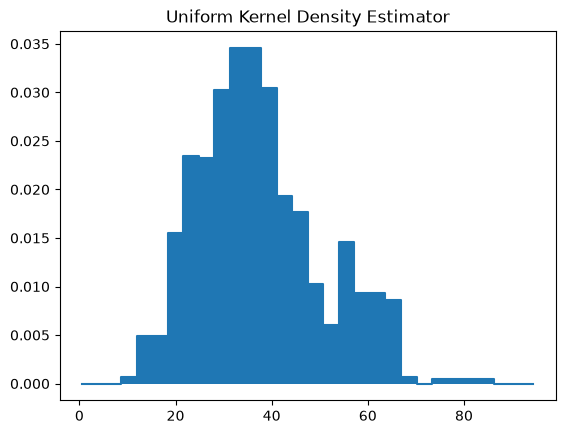

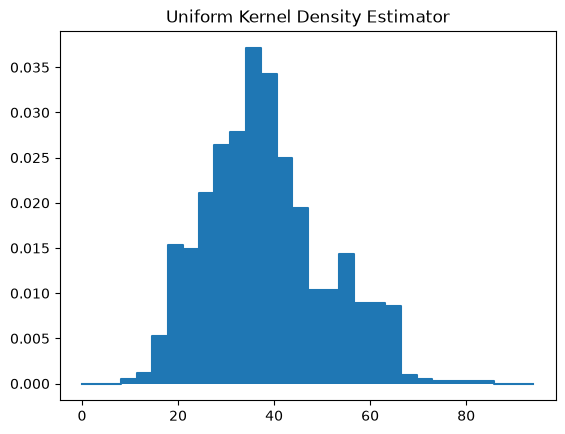

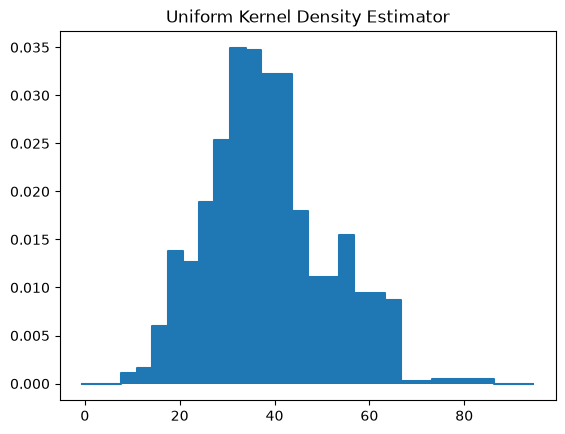

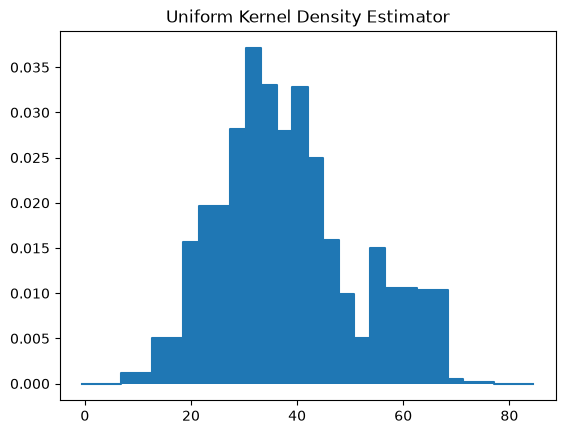

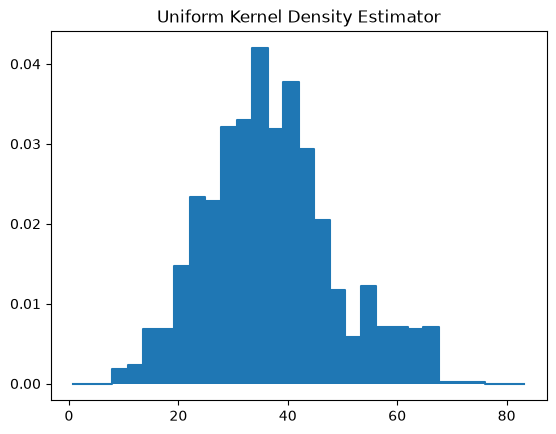

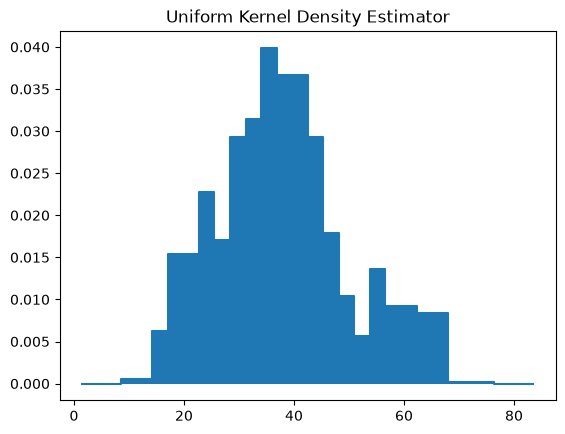

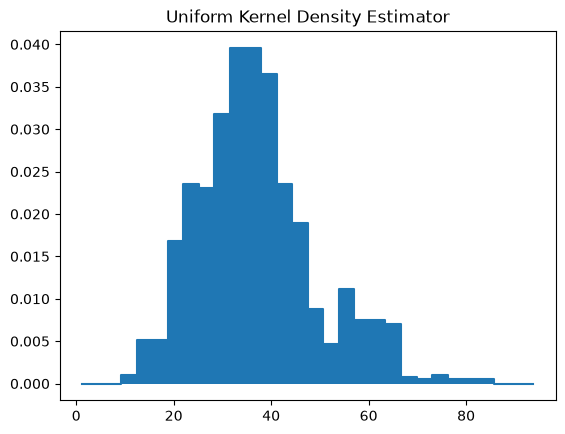

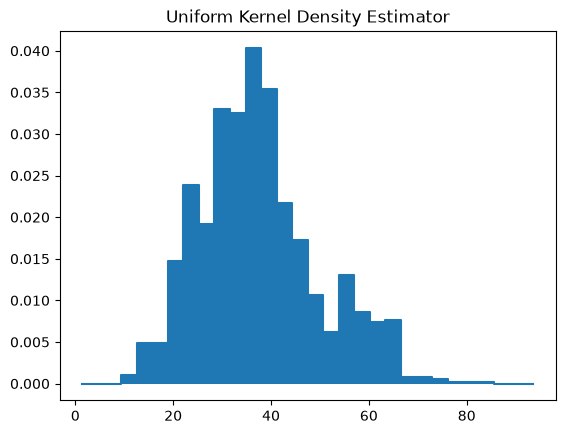

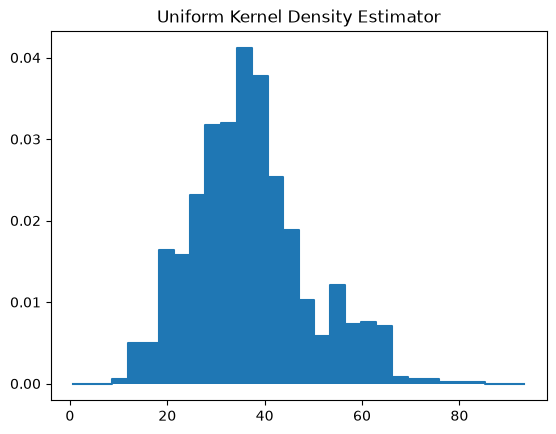

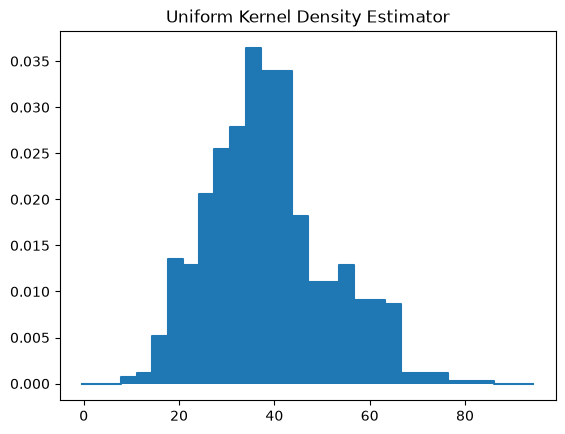

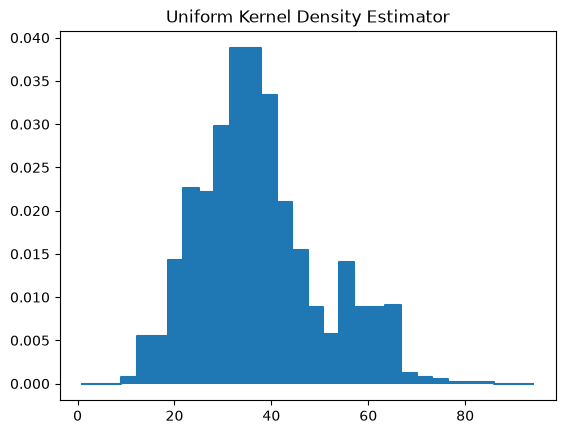

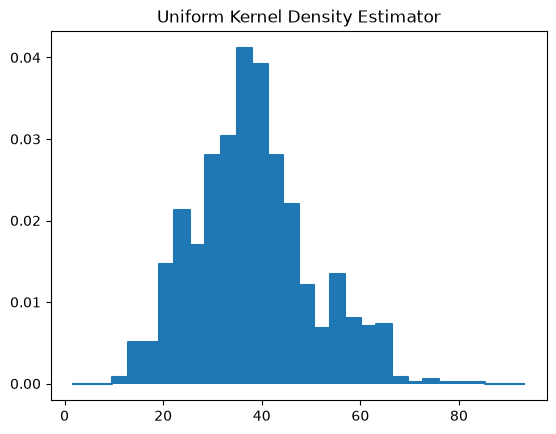

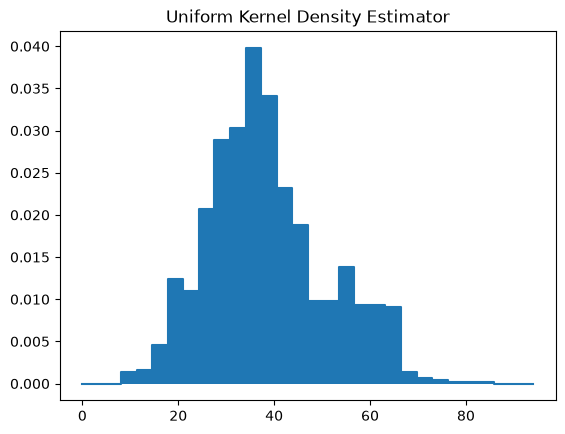

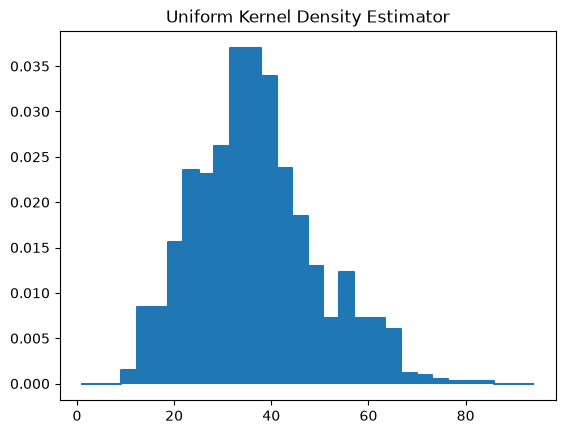

In [12]:
for i in range(15):
    sample = df.sample(frac=1.0, replace=True)
    kde(sample["ejection_fraction"])

##### Part C

I would say that probably between about 20 and 50 the values from the original KDE hold up. The center is always around 35-40, reaching a density between .35 and .4. 20 is always around .15 and 50 is always around .1. Eveyrthing in between that stays pretty regular, but the tails fluctuate a decent amount. This makes sense, because as we resample, those less common extremes might not get sampled, or sampled as much as they appear in the data, so they can start to look a bit different sample to sample. In this sample, anything above 50 and below 20 looks fairly different sample to sample. 